In [139]:
# Parameters
param1=1

In [140]:
from matplotlib import pyplot as plt

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce



In [141]:
A = 10
S = 40
X = []
y = []
actions_in = [[1,0,0], [0,1,0], [0,0,1]]
actions = [-1, 0, 1]
states_obs = np.eye(S)

for s in range(S):
    for a, a_in in zip(actions, actions_in):
        if a == 0:
            continue
        for n_actions in range(1, A+1):
            s_curr = s
            a_curr = a
            a_in_curr = a_in
            X_curr = []
            y_curr = []
            for action_num in range(A):
                if action_num > n_actions:
                    a_curr = 0
                    a_in_curr = actions_in[1]
                X_curr.append(np.concatenate([states_obs[s_curr]*int(action_num==0), a_in_curr]))
                s_curr = (s_curr + a_curr) % S
                y_curr.append(states_obs[s_curr])
            X.append(X_curr)
            y.append(y_curr)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)




(800, 10, 43)
(800, 10, 40)


In [142]:
action_num

9

In [143]:
import torch
import torch.nn as nn
import torch.optim as optim

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Prepare data for PyTorch: (N, T, F)
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)  # shape: (N, T, F)
y_tensor = torch.tensor(y, dtype=torch.float32, device=device)  # shape: (N, T, F_s)

N, T, F = X_tensor.shape
_, _, F_s = y_tensor.shape

# For classification (one-hot to class index)
y_class = torch.argmax(y_tensor, dim=2).to(device)  # shape: (N, T)

# Standard PyTorch RNN module with L layers

class StandardRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(StandardRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,      # input (N, T, F)
            nonlinearity='tanh'
        )
        self.fc = nn.Linear(hidden_size, output_size, bias=False)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch_size = x.size(0)
        device = x.device
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        out_rnn, h_n = self.rnn(x, h0)                  # out_rnn: (N, T, hidden)
        outputs = self.fc(out_rnn)                       # (N, T, output_size)
        # Optionally collect all hidden states for visualization (reshape for compatibility)
        h_l = out_rnn.detach().cpu().numpy()             # (N, T, hidden_size)
        return outputs, h_l

hidden_size = 125  # You can adjust this
num_layers = 10     # Set number of layers as desired

model = StandardRNN(X.shape[2], hidden_size, y.shape[2], num_layers=num_layers).to(device)

# For multiclass classification, target = class indices (Long tensor), input = logits (float tensor)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

n_epochs = 5000

from tqdm import trange

progress_bar = trange(n_epochs, desc="Training", leave=True)
for epoch in progress_bar:
    optimizer.zero_grad()
    output, h_l = model(X_tensor)  # (N, T, F_s)
    # CrossEntropyLoss expects (N, C) and (N) for 2d case, so flatten batch and seq
    output_flat = output.view(-1, F_s)
    target_flat = y_class.view(-1)
    loss = criterion(output_flat, target_flat)
    loss.backward()
    optimizer.step()
    # Calculate accuracy
    with torch.no_grad():
        preds = torch.argmax(output, dim=2)  # (N, T)
        correct = (preds == y_class).float().sum()
        total = preds.numel()
        accuracy = correct / total
    # Update tqdm progress bar with loss and accuracy info
    progress_bar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "Acc": f"{accuracy.item():.4f}"
    })


Using device: cuda


Training:   0%|          | 0/5000 [00:00<?, ?it/s, Loss=3.6890, Acc=0.0250]

Training: 100%|██████████| 5000/5000 [00:48<00:00, 102.08it/s, Loss=0.3319, Acc=0.9380]


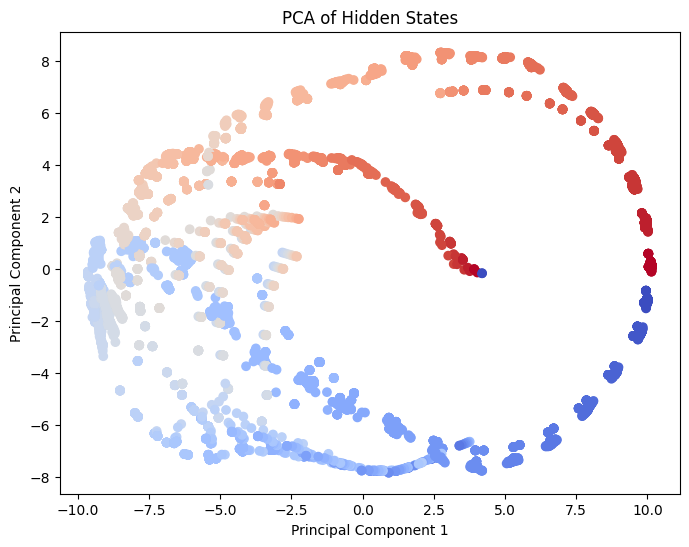

In [144]:
hidden = np.array(h_l)
hidden_reshaped = hidden.reshape(-1, hidden.shape[2]).T  # shape: (neurons, time*batch)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA(n_components=2)
hidden_pca = pca.fit_transform(hidden_reshaped.T)
target_pos = y.reshape(-1, S).argmax(axis=1)
# Plot
plt.figure(figsize=(8,6))
plt.scatter(hidden_pca[:, 0], hidden_pca[:, 1], c=target_pos, cmap='coolwarm')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Hidden States')
plt.show()



In [ ]:
print(X[:,:,:30].argmax(-1)[101])
y[:,:].argmax(-1)[101]

[5 0 0 0 0 0 0 0 0 0]


array([4, 3, 2, 2, 2, 2, 2, 2, 2, 2])

: 